In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


In [2]:
df = pd.read_csv("customer_retail.csv")

In [3]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [4]:
df =df.dropna()

In [5]:
df = df[['Quantity', 'UnitPrice','Country']]

In [6]:
encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])

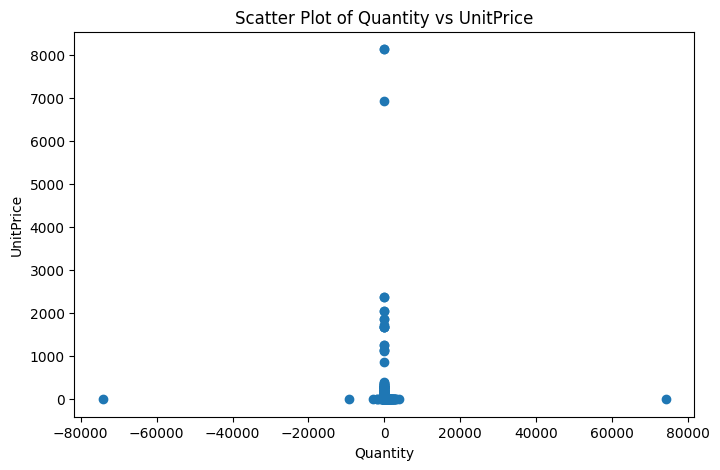

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()

In [8]:
x =df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [10]:

print("Logistics Regression")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)
y_pred = log_model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix: \n")
print(cm)

print("Decision Tree")
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred = dt_model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))

print("KNN")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train,y_train)
y_pred = knn_model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))


Logistics Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8953085278483938
Confusion Matrix: 

[[    0     0     0 ...     0    70     0]
 [    0     0     0 ...     0    16     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0     8     0]
 [    0     0     0 ...     0 23244     0]
 [    0     0     0 ...     0    13     0]]
Decision Tree
Accuracy: 0.8959633310222633
[[    6     0     0 ...     0    60     0]
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0     8     0]
 [   20     0     0 ...     0 23165     0]
 [    0     0     0 ...     0    13     0]]
KNN
Accuracy: 0.8816346968646483
[[    4     0     0 ...     0    61     0]
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0     8     0]
 [   24     0     0 ...     0 22796     0]
 [    0     0     0 ...     0    13     0]]


In [11]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [accuracy, accuracy, accuracy]

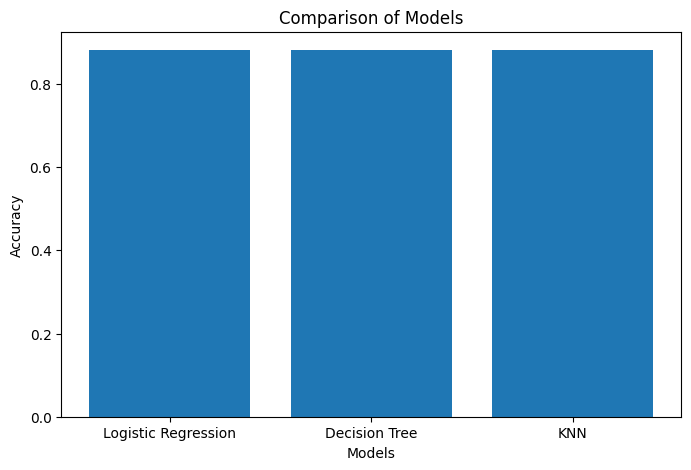

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Models')
plt.show()